In [1]:
import tensorflow as tf 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

2026-04-08 17:48:51.395636: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775670531.771355      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775670531.886356      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775670532.861757      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775670532.861797      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775670532.861799      55 computation_placer.cc:177] computation placer alr

In [2]:
(X_train,y_train),(X_test,y_test)=tf.keras.datasets.imdb.load_data()

X_train=tf.keras.preprocessing.sequence.pad_sequences(X_train,maxlen=200)
X_test=tf.keras.preprocessing.sequence.pad_sequences(X_test,maxlen=200)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
model=tf.keras.models.Sequential()

model.add(tf.keras.layers.Input(shape=(200,)))
model.add(tf.keras.layers.Embedding(10000,128))
model.add(tf.keras.layers.LSTM(128))
model.add(tf.keras.layers.Dense(1,activation='sigmoid'))

model.summary()

I0000 00:00:1775670578.374887      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775670578.380817      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,411,713 (5.39 MB)

 Trainable params: 1,411,713 (5.39 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
early=tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [5]:
history=model.fit(X_train,y_train,epochs=10,validation_split=0.2,callbacks=[early])

Epoch 1/10


I0000 00:00:1775670582.671793     127 cuda_dnn.cc:529] Loaded cuDNN version 91002


625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.7102 - loss: 0.5321 - val_accuracy: 0.8534 - val_loss: 0.3592
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8866 - loss: 0.2859 - val_accuracy: 0.8698 - val_loss: 0.3429
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9319 - loss: 0.1830 - val_accuracy: 0.8590 - val_loss: 0.3645
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9549 - loss: 0.1254 - val_accuracy: 0.8648 - val_loss: 0.4346


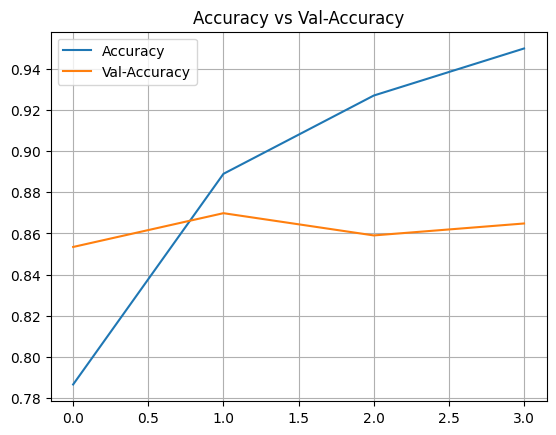

In [6]:
plt.plot(history.history['accuracy'],label='Accuracy')
plt.plot(history.history['val_accuracy'],label='Val-Accuracy')
plt.grid()
plt.legend()
plt.title('Accuracy vs Val-Accuracy')
plt.show()

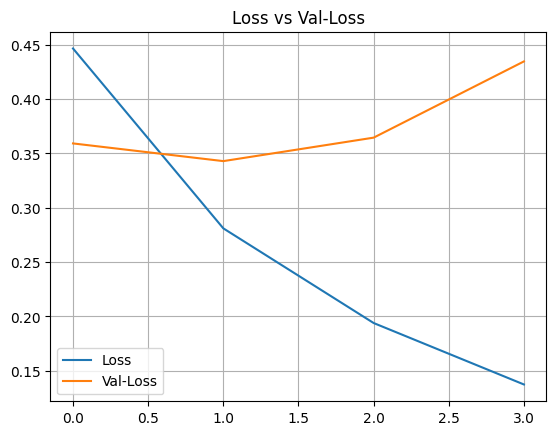

In [7]:
plt.plot(history.history['loss'],label='Loss')
plt.plot(history.history['val_loss'],label='Val-Loss')
plt.grid()
plt.legend()
plt.title('Loss vs Val-Loss')
plt.show()

In [8]:
loss,acc=model.evaluate(X_test,y_test)
print(f"Loss : {loss:.4f} Accuracy : {acc*100:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8651 - loss: 0.3526
Loss : 0.3504 Accuracy : 86.4200


In [9]:
while True:
    sent=input("Enter you review or to exit type exit")
    if sent=='exit':
        break
    word_ind=tf.keras.datasets.imdb.get_word_index()
    ind=[1]
    sen=sent.lower().split()
    for i in sent:
        ind.append(word_ind.get(i,2))
    final=tf.keras.preprocessing.sequence.pad_sequences([ind],maxlen=200)
    if model.predict(final)[0]>0.5:
        print('Negative Review')
    else:
        print('Positive Review')

Enter you review or to exit type exit I really loved this film it was inspiring and beautifully directed


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
Positive Review


Enter you review or to exit type exit exit
